# Libraries

In [4]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

#Display's plots inside notebook
%matplotlib inline

#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# keeping Dataset Paths

In [5]:
# Dataset paths
TRAIN_DIR = Path("../data/raw/Training")
TEST_DIR = Path("../data/raw/Testing")

print("Training Folder:", TRAIN_DIR)
print("Testing Folder :", TEST_DIR)

Training Folder: ..\data\raw\Training
Testing Folder : ..\data\raw\Testing


# Class Names

In [6]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Classes Found:\n")

for cls in classes:
    print(cls)

Classes Found:

glioma
meningioma
notumor
pituitary


# Training images count

In [8]:
train_counts = {}

for cls in classes:
    folder = TRAIN_DIR / cls
    train_counts[cls] = len(list(folder.glob("*")))

train_df = pd.DataFrame(
    train_counts.items(),
    columns=["Class", "Training Images"]
)

train_df

,Class,Training Images
0,glioma,1400
1,meningioma,1400
2,notumor,1400
3,pituitary,1400


# Testing Images count

In [9]:
test_counts = {}

for cls in classes:
    folder = TEST_DIR / cls
    test_counts[cls] = len(list(folder.glob("*")))

test_df = pd.DataFrame(
    test_counts.items(),
    columns=["Class", "Testing Images"]
)

test_df

,Class,Testing Images
0,glioma,400
1,meningioma,400
2,notumor,400
3,pituitary,400


# count of all images by class

In [10]:
dataset_info = train_df.merge(
    test_df,
    on="Class"
)

dataset_info["Total"] = (
    dataset_info["Training Images"] +
    dataset_info["Testing Images"]
)

dataset_info

,Class,Training Images,Testing Images,Total
0,glioma,1400,400,1800
1,meningioma,1400,400,1800
2,notumor,1400,400,1800
3,pituitary,1400,400,1800


# Summary of the Dataset

In [11]:
print("Dataset Summary")
print("=" * 40)

print(f"Number of Classes : {len(classes)}")
print(f"Training Images   : {dataset_info['Training Images'].sum()}")
print(f"Testing Images    : {dataset_info['Testing Images'].sum()}")
print(f"Total Images      : {dataset_info['Total'].sum()}")

Dataset Summary
Number of Classes : 4
Training Images   : 5600
Testing Images    : 1600
Total Images      : 7200


# Exploratory Data Analysis (EDA)

### MRI Sample Images

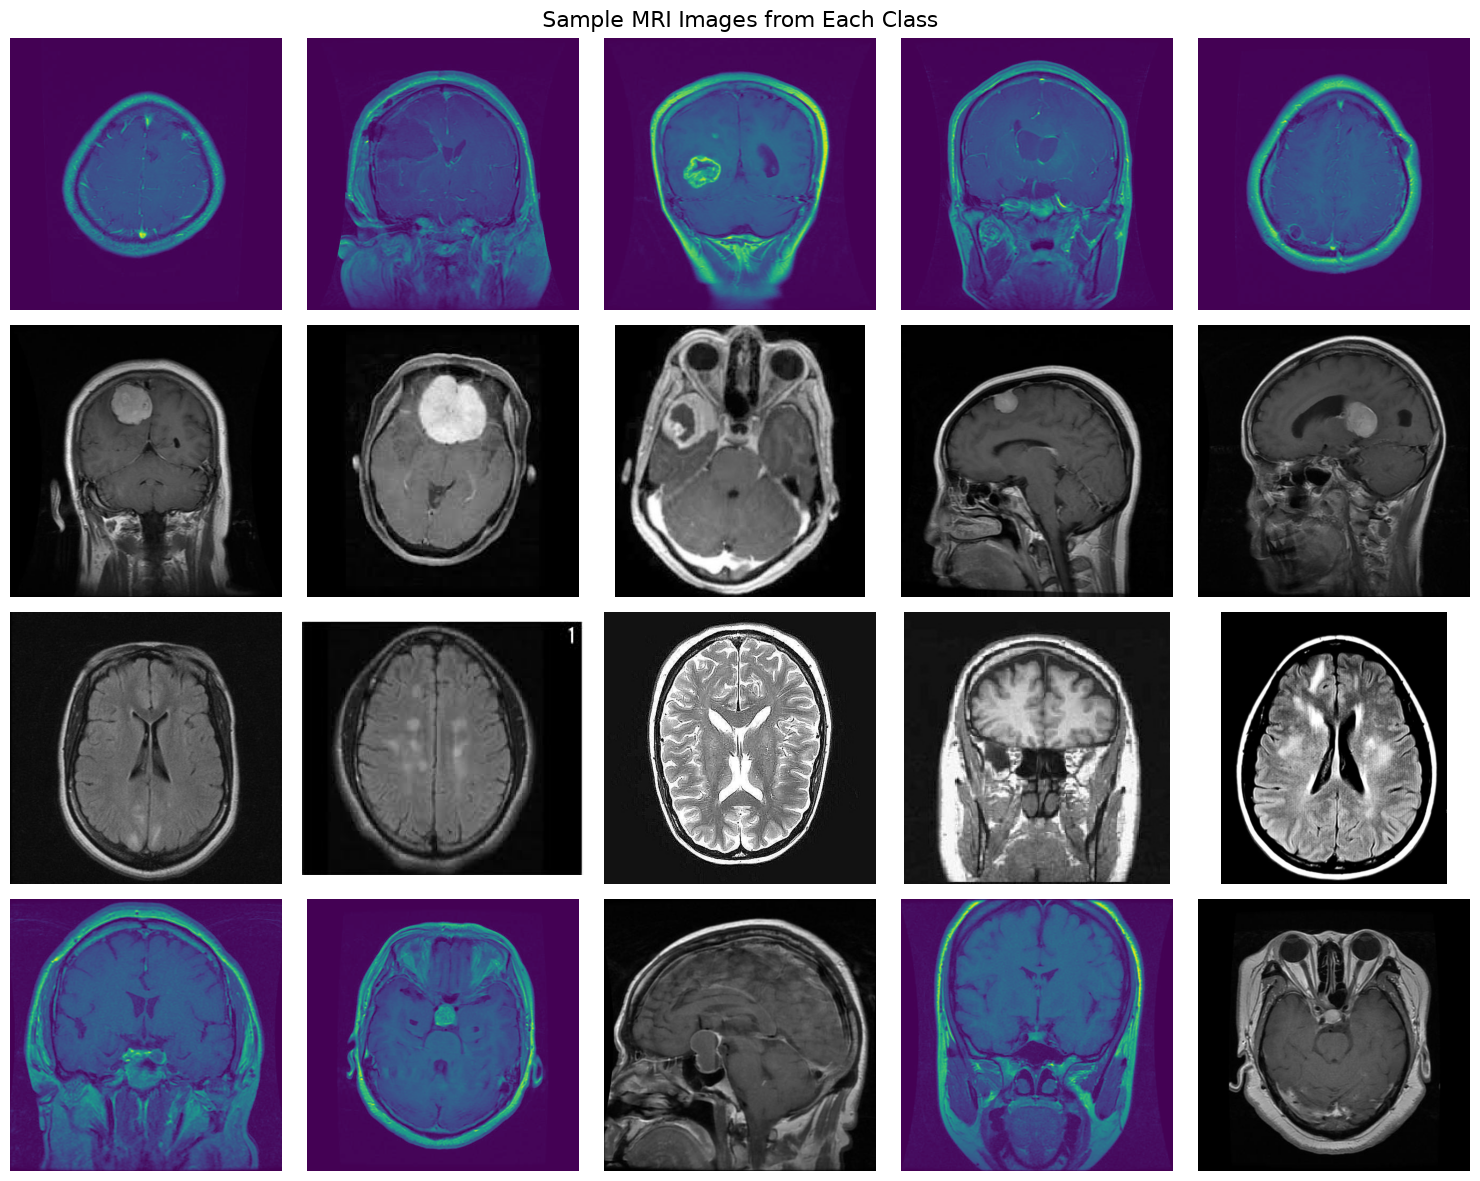

In [12]:
import random

fig, axes = plt.subplots(len(classes), 5, figsize=(15, 12))

for row, cls in enumerate(classes):
    image_paths = list((TRAIN_DIR / cls).glob("*"))
    random_images = random.sample(image_paths, 5)

    for col, img_path in enumerate(random_images):
        img = Image.open(img_path)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12)

plt.suptitle("Sample MRI Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

# Image Size Analysis

In [13]:
widths = []
heights = []

for cls in classes:
    image_paths = list((TRAIN_DIR / cls).glob("*"))

    for img_path in image_paths:
        img = Image.open(img_path)
        w, h = img.size

        widths.append(w)
        heights.append(h)

In [14]:
print("Image Size Statistics")
print("-" * 30)

print(f"Minimum Width  : {min(widths)}")
print(f"Maximum Width  : {max(widths)}")
print(f"Average Width  : {np.mean(widths):.2f}")

print()

print(f"Minimum Height : {min(heights)}")
print(f"Maximum Height : {max(heights)}")
print(f"Average Height : {np.mean(heights):.2f}")

Image Size Statistics
------------------------------
Minimum Width  : 150
Maximum Width  : 1375
Average Width  : 458.51

Minimum Height : 168
Maximum Height : 1446
Average Height : 462.26


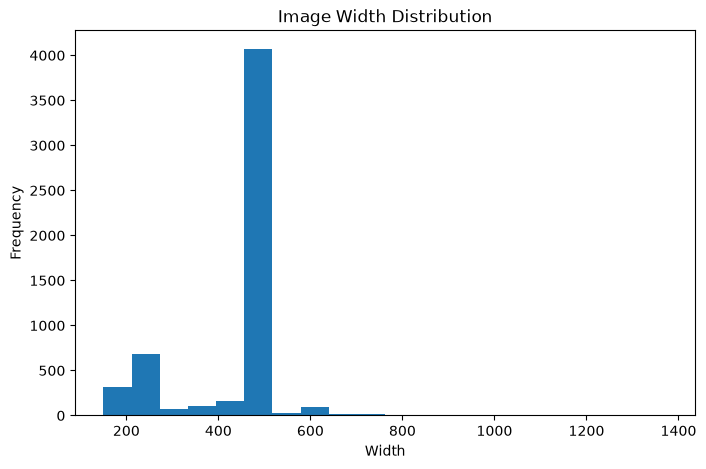

In [15]:
plt.figure(figsize=(8,5))

plt.hist(widths, bins=20)

plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

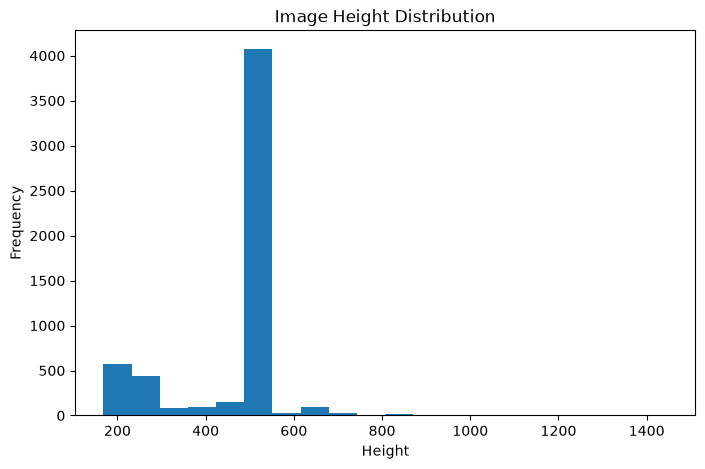

In [16]:
plt.figure(figsize=(8,5))

plt.hist(heights, bins=20)

plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

# Image Format Analysis

In [17]:
from collections import Counter

extensions = []

for cls in classes:
    for img_path in (TRAIN_DIR / cls).glob("*"):
        extensions.append(img_path.suffix.lower())

Counter(extensions)

Counter({'.jpg': 5600})

# Corrupted Image Detection

In [18]:
corrupted = []

for cls in classes:
    for img_path in (TRAIN_DIR / cls).glob("*"):
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception:
            corrupted.append(img_path)

In [19]:
print(f"Total Corrupted Images: {len(corrupted)}")

if corrupted:
    for img in corrupted[:10]:
        print(img)
else:
    print("No corrupted images found.")

Total Corrupted Images: 0
No corrupted images found.


# Pixel Statistics

In [21]:
sum_rgb = np.zeros(3)
sum_sq_rgb = np.zeros(3)
num_pixels = 0

for cls in classes:
    image_paths = list((TRAIN_DIR / cls).glob("*"))

    for img_path in image_paths:
        img = Image.open(img_path).convert("RGB")
        img = np.array(img, dtype=np.float32) / 255.0

        pixels = img.reshape(-1, 3)

        sum_rgb += pixels.sum(axis=0)
        sum_sq_rgb += (pixels ** 2).sum(axis=0)
        num_pixels += pixels.shape[0]

mean = sum_rgb / num_pixels
std = np.sqrt((sum_sq_rgb / num_pixels) - (mean ** 2))

print("Mean RGB :", mean)
print("Std RGB  :", std)

Mean RGB : [0.173572   0.17357321 0.17358479]
Std RGB  : [0.18762258 0.18762173 0.18762758]


# Aspect Ratio Analysis

In [22]:
aspect_ratios = []

for w, h in zip(widths, heights):
    aspect_ratios.append(round(w / h, 2))

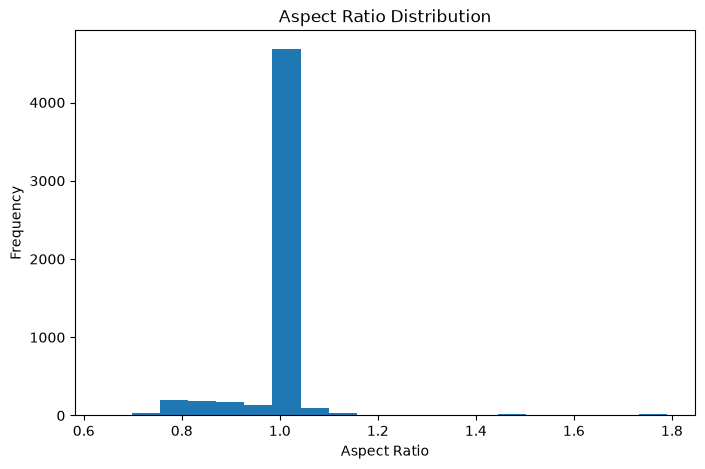

In [23]:
plt.figure(figsize=(8,5))

plt.hist(aspect_ratios, bins=20)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")

plt.show()

# EDA Conclusion

In [24]:
print("=" * 50)
print("EDA Summary")
print("=" * 50)

print(f"Number of Classes        : {len(classes)}")
print(f"Total Images             : {dataset_info['Total'].sum()}")
print(f"Dataset Balanced         : Yes")
print(f"Corrupted Images         : {len(corrupted)}")
print(f"Unique Image Formats     : {set(extensions)}")
print(f"Average Width            : {np.mean(widths):.2f}")
print(f"Average Height           : {np.mean(heights):.2f}")
print(f"Mean Pixel Values (RGB)  : {mean}")
print(f"Std Pixel Values (RGB)   : {std}")

EDA Summary
Number of Classes        : 4
Total Images             : 7200
Dataset Balanced         : Yes
Corrupted Images         : 0
Unique Image Formats     : {'.jpg'}
Average Width            : 458.51
Average Height           : 462.26
Mean Pixel Values (RGB)  : [0.173572   0.17357321 0.17358479]
Std Pixel Values (RGB)   : [0.18762258 0.18762173 0.18762758]


# Saving EDA Outputs

In [25]:
OUTPUT_DIR = Path("../outputs/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
# Saving dataset summary
dataset_info.to_csv(
    OUTPUT_DIR / "dataset_summary.csv",
    index=False
)

print("Dataset summary saved successfully.")

Dataset summary saved successfully.


In [27]:
#Saving Image Size Statistics
size_stats = {
    "Minimum Width": min(widths),
    "Maximum Width": max(widths),
    "Average Width": round(np.mean(widths), 2),
    "Minimum Height": min(heights),
    "Maximum Height": max(heights),
    "Average Height": round(np.mean(heights), 2)
}

size_df = pd.DataFrame(size_stats.items(), columns=["Metric", "Value"])

size_df.to_csv(
    OUTPUT_DIR / "image_size_statistics.csv",
    index=False
)

size_df

,Metric,Value
0,Minimum Width,150.00
1,Maximum Width,1375.00
2,Average Width,458.51
3,Minimum Height,168.00
4,Maximum Height,1446.00
5,Average Height,462.26


In [28]:
#Saving Pixel Statistics
pixel_df = pd.DataFrame({
    "Channel": ["Red", "Green", "Blue"],
    "Mean": mean,
    "Std": std
})

pixel_df.to_csv(
    OUTPUT_DIR / "pixel_statistics.csv",
    index=False
)

pixel_df

,Channel,Mean,Std
0,Red,0.173572,0.187623
1,Green,0.173573,0.187622
2,Blue,0.173585,0.187628


In [29]:
#Saving Aspect Ratio Statistics
aspect_df = pd.DataFrame({
    "Aspect Ratio": aspect_ratios
})

aspect_df.describe()

,Aspect Ratio
count,5600.000000
mean,0.988416
std,0.079426
min,0.640000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.790000


In [30]:
aspect_df.to_csv(
    OUTPUT_DIR / "aspect_ratio_statistics.csv",
    index=False
)

# EDA Conclusion

The exploratory data analysis confirms that:

- The dataset contains four classes.
- The dataset is balanced across all classes.
- No corrupted images were detected.
- Images have consistent dimensions and aspect ratios.
- Pixel statistics were computed for normalization.
- The dataset is suitable for preprocessing and training an EfficientNet-B0 model.